In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from torch_models import ConvNet, make_loader, predict_probabilities
torch.set_num_threads(2)
_, _, test = split_paths()
keras_model = tf.keras.models.load_model(ROOT / "models" / "keras_cnn.keras")
pytorch_model = ConvNet()
pytorch_model.load_state_dict(torch.load(ROOT / "models" / "pytorch_cnn.pth", map_location="cpu", weights_only=True))
keras_prob = keras_model.predict(load_array(test[0]), verbose=0).reshape(-1)
pytorch_prob = predict_probabilities(pytorch_model, make_loader(*test))
comparison = {"Keras CNN": evaluate_binary(test[1], keras_prob), "PyTorch CNN": evaluate_binary(test[1], pytorch_prob)}
table = pd.DataFrame(comparison).T[["accuracy", "precision", "recall", "f1", "roc_auc", "log_loss"]]
print(table.round(4).to_string())
table.to_csv(ROOT / "results" / "compare_cnn.csv")


             accuracy precision    recall        f1   roc_auc  log_loss
Keras CNN    0.930556       1.0  0.861111  0.925373  0.968364  0.427624
PyTorch CNN  0.861111       1.0  0.722222   0.83871  0.925154  0.451605


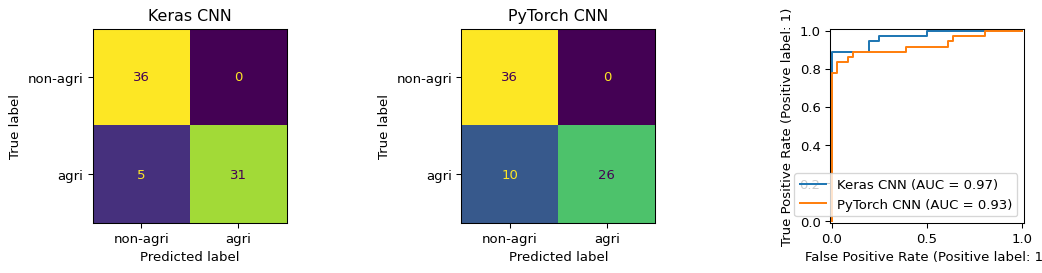

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for axis, (name, result) in zip(axes[:2], comparison.items()):
    ConfusionMatrixDisplay(np.asarray(result["confusion_matrix"]), display_labels=("non-agri", "agri")).plot(ax=axis, colorbar=False)
    axis.set_title(name)
RocCurveDisplay.from_predictions(test[1], keras_prob, ax=axes[2], name="Keras CNN")
RocCurveDisplay.from_predictions(test[1], pytorch_prob, ax=axes[2], name="PyTorch CNN")
plt.tight_layout()
plt.show()
